<a href="https://colab.research.google.com/github/radhikatyagi388/Ai_60_Day_Challange/blob/main/Teaching_AI_Semantic_Meaning_Through_Vectors.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
# Day 9: Teaching AI Semantic Meaning Through Vectors

## Objective

In this project, we will learn how computers represent text numerically and compare the similarity between different sentences.

We will use:

- Python
- NumPy
- scikit-learn
- matplotlib
- TF-IDF Vectorization
- Cosine Similarity

The workflow will be:

Text → TF-IDF Vectors → Cosine Similarity → Similarity Matrix → Visualization

In [ ]:
## Why can't computers directly compare plain text?

Humans can easily understand that words such as "dog" and "puppy" are related. However, a computer does not naturally understand the meaning of words. It processes numerical values.

For example, a computer cannot directly calculate:

"the dog is friendly" vs "the puppy is playful"

using normal mathematical operations on the raw text.

Therefore, text must first be converted into numerical vectors.

A vector is a collection of numbers that represents the important characteristics of a piece of text.

In this project, we use TF-IDF (Term Frequency-Inverse Document Frequency) to convert sentences into numerical vectors.

Once sentences are represented as vectors, mathematical operations can be performed on them. Cosine similarity can then be used to measure how similar two text vectors are.

The overall process is:

Raw Text
↓
TF-IDF Vectorization
↓
Numerical Vectors
↓
Cosine Similarity
↓
Similarity Score

In [4]:
import numpy as np
import matplotlib.pyplot as plt

from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.metrics.pairwise import cosine_similarity

In [5]:
sentences = [
    "The dog is a loyal and friendly pet that loves people.",
    "The puppy is a playful and friendly pet that loves people.",
    "The puppy enjoys playing with its owner in the park.",
    "Many dogs enjoy running and playing outdoors with people.",

    "The airplane flew across the sky during the morning.",
    "Passengers boarded the airplane for a long international flight.",
    "The pilot prepared the aircraft for takeoff at the airport.",

    "Python is a popular programming language for artificial intelligence.",
    "Machine learning algorithms can analyze data and make predictions.",
    "Artificial intelligence helps computers learn from large amounts of data."
]

for i, sentence in enumerate(sentences):
    print(f"{i}: {sentence}")

0: The dog is a loyal and friendly pet that loves people.
1: The puppy is a playful and friendly pet that loves people.
2: The puppy enjoys playing with its owner in the park.
3: Many dogs enjoy running and playing outdoors with people.
4: The airplane flew across the sky during the morning.
5: Passengers boarded the airplane for a long international flight.
6: The pilot prepared the aircraft for takeoff at the airport.
7: Python is a popular programming language for artificial intelligence.
8: Machine learning algorithms can analyze data and make predictions.
9: Artificial intelligence helps computers learn from large amounts of data.


In [6]:
vectorizer = TfidfVectorizer(stop_words='english')

tfidf_matrix = vectorizer.fit_transform(sentences)

print("TF-IDF Matrix Shape:", tfidf_matrix.shape)

TF-IDF Matrix Shape: (10, 48)


In [7]:
feature_names = vectorizer.get_feature_names_out()

print("Number of features:", len(feature_names))
print("\nVocabulary:")
print(feature_names)

Number of features: 48

Vocabulary:
['aircraft' 'airplane' 'airport' 'algorithms' 'amounts' 'analyze'
 'artificial' 'boarded' 'computers' 'data' 'dog' 'dogs' 'enjoy' 'enjoys'
 'flew' 'flight' 'friendly' 'helps' 'intelligence' 'international'
 'language' 'large' 'learn' 'learning' 'long' 'loves' 'loyal' 'machine'
 'make' 'morning' 'outdoors' 'owner' 'park' 'passengers' 'people' 'pet'
 'pilot' 'playful' 'playing' 'popular' 'predictions' 'prepared'
 'programming' 'puppy' 'python' 'running' 'sky' 'takeoff']


In [8]:
similarity_matrix = cosine_similarity(tfidf_matrix)

print("Similarity Matrix Shape:", similarity_matrix.shape)

print("\nSimilarity Matrix:")
print(np.round(similarity_matrix, 2))

Similarity Matrix Shape: (10, 10)

Similarity Matrix:
[[1.   0.59 0.   0.11 0.   0.   0.   0.   0.   0.  ]
 [0.59 1.   0.16 0.11 0.   0.   0.   0.   0.   0.  ]
 [0.   0.16 1.   0.15 0.   0.   0.   0.   0.   0.  ]
 [0.11 0.11 0.15 1.   0.   0.   0.   0.   0.   0.  ]
 [0.   0.   0.   0.   1.   0.16 0.   0.   0.   0.  ]
 [0.   0.   0.   0.   0.16 1.   0.   0.   0.   0.  ]
 [0.   0.   0.   0.   0.   0.   1.   0.   0.   0.  ]
 [0.   0.   0.   0.   0.   0.   0.   1.   0.   0.23]
 [0.   0.   0.   0.   0.   0.   0.   0.   1.   0.1 ]
 [0.   0.   0.   0.   0.   0.   0.   0.23 0.1  1.  ]]


In [ ]:
## Cosine Similarity

Cosine similarity measures the angle between two vectors rather than directly measuring the distance between them.

The formula is:

cos(θ) = (A · B) / (||A|| ||B||)

where:

A · B = dot product of vectors A and B

||A|| = magnitude of vector A

||B|| = magnitude of vector B

The result normally ranges from:

1   → very similar
0   → no similarity
-1  → opposite direction

For TF-IDF text vectors, values are generally between 0 and 1 because the feature values are non-negative.

### Why angle instead of distance?

Text documents can have different lengths.

For example:

Sentence A:
"dog friendly pet"

Sentence B:
"dog friendly pet dog dog dog dog"

The second sentence is longer, but the important words may still point in a similar direction in vector space.

Euclidean distance can be strongly affected by the magnitude or length of the vectors.

Cosine similarity focuses on the orientation of the vectors.

Therefore, two documents can have different lengths but still have a high cosine similarity if they contain similar word patterns.

This makes cosine similarity useful for comparing documents, sentences, search queries, and other text representations.

In [9]:
def find_similar(query, corpus, top_k=3):

    # Create a vectorizer
    vectorizer = TfidfVectorizer(stop_words='english')

    # Convert corpus into TF-IDF vectors
    corpus_vectors = vectorizer.fit_transform(corpus)

    # Convert query into the same vector space
    query_vector = vectorizer.transform([query])

    # Calculate similarity between query and every corpus sentence
    scores = cosine_similarity(query_vector, corpus_vectors)[0]

    # Get indices of highest similarity scores
    top_indices = np.argsort(scores)[::-1][:top_k]

    # Store results
    results = []

    for index in top_indices:
        results.append((corpus[index], scores[index]))

    return results

In [10]:
query = "A puppy is a friendly pet that loves people."

results = find_similar(query, sentences, top_k=5)

print("Query:", query)
print("\nMost Similar Sentences:\n")

for sentence, score in results:
    print(f"Score: {score:.4f} → {sentence}")

Query: A puppy is a friendly pet that loves people.

Most Similar Sentences:

Score: 0.8803 → The puppy is a playful and friendly pet that loves people.
Score: 0.6748 → The dog is a loyal and friendly pet that loves people.
Score: 0.1847 → The puppy enjoys playing with its owner in the park.
Score: 0.1298 → Many dogs enjoy running and playing outdoors with people.
Score: 0.0000 → Machine learning algorithms can analyze data and make predictions.


In [11]:
query = "A dog is a friendly pet."

results = find_similar(query, sentences, top_k=5)

print("Query:", query)
print("\nResults:\n")

for sentence, score in results:
    print(f"Score: {score:.4f} → {sentence}")

Query: A dog is a friendly pet.

Results:

Score: 0.7197 → The dog is a loyal and friendly pet that loves people.
Score: 0.4384 → The puppy is a playful and friendly pet that loves people.
Score: 0.0000 → Machine learning algorithms can analyze data and make predictions.
Score: 0.0000 → Artificial intelligence helps computers learn from large amounts of data.
Score: 0.0000 → Python is a popular programming language for artificial intelligence.


In [12]:
test_queries = [
    "A puppy is a friendly pet.",
    "A dog enjoys playing outdoors.",
    "An airplane carries passengers.",
    "A pilot prepares an aircraft for takeoff.",
    "Machine learning helps computers analyze data.",
    "Python is used for artificial intelligence."
]

for query in test_queries:

    print("=" * 80)
    print("QUERY:", query)

    results = find_similar(query, sentences, top_k=3)

    for sentence, score in results:
        print(f"{score:.4f} → {sentence}")

QUERY: A puppy is a friendly pet.
0.6985 → The puppy is a playful and friendly pet that loves people.
0.4518 → The dog is a loyal and friendly pet that loves people.
0.2328 → The puppy enjoys playing with its owner in the park.
QUERY: A dog enjoys playing outdoors.
0.4235 → The puppy enjoys playing with its owner in the park.
0.3887 → Many dogs enjoy running and playing outdoors with people.
0.2385 → The dog is a loyal and friendly pet that loves people.
QUERY: An airplane carries passengers.
0.5487 → Passengers boarded the airplane for a long international flight.
0.2854 → The airplane flew across the sky during the morning.
0.0000 → Machine learning algorithms can analyze data and make predictions.
QUERY: A pilot prepares an aircraft for takeoff.
0.7746 → The pilot prepared the aircraft for takeoff at the airport.
0.0000 → Artificial intelligence helps computers learn from large amounts of data.
0.0000 → Machine learning algorithms can analyze data and make predictions.
QUERY: Machin

In [13]:
def compare_sentences(sentence1, sentence2):

    vectorizer = TfidfVectorizer(stop_words='english')

    vectors = vectorizer.fit_transform([sentence1, sentence2])

    score = cosine_similarity(vectors[0], vectors[1])[0][0]

    return score

In [14]:
dog_sentence = "The dog is a loyal and friendly pet that loves people."

puppy_sentence = "The puppy is a playful and friendly pet that loves people."

airplane_sentence = "The airplane flew across the sky during the morning."

In [15]:
dog_puppy = compare_sentences(dog_sentence, puppy_sentence)

dog_airplane = compare_sentences(dog_sentence, airplane_sentence)

print("Dog vs Puppy:", round(dog_puppy, 4))
print("Dog vs Airplane:", round(dog_airplane, 4))

Dog vs Puppy: 0.5031
Dog vs Airplane: 0.0


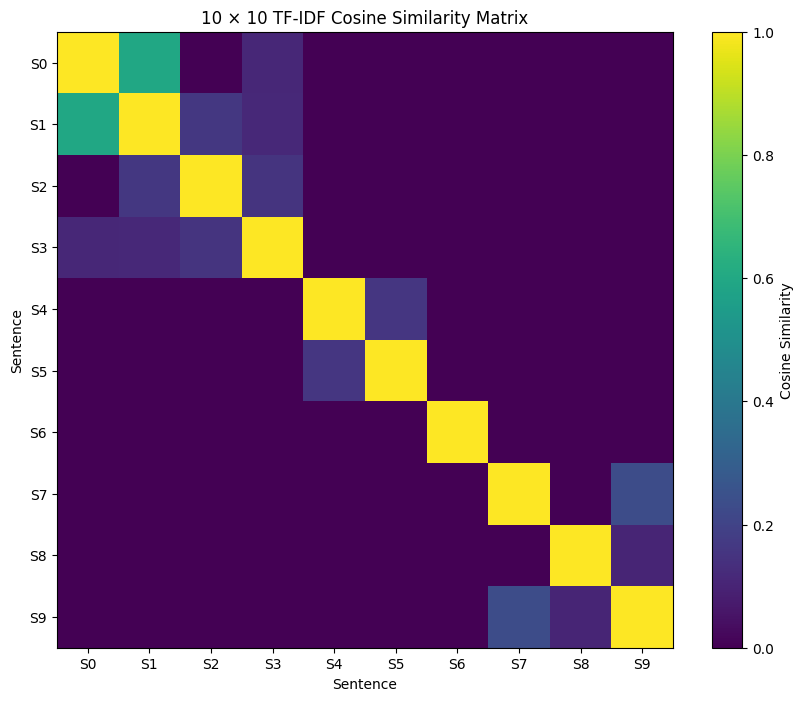

In [16]:
plt.figure(figsize=(10, 8))

plt.imshow(similarity_matrix, interpolation='nearest')

plt.colorbar(label='Cosine Similarity')

plt.xticks(
    range(len(sentences)),
    [f"S{i}" for i in range(len(sentences))]
)

plt.yticks(
    range(len(sentences)),
    [f"S{i}" for i in range(len(sentences))]
)

plt.xlabel("Sentence")
plt.ylabel("Sentence")
plt.title("10 × 10 TF-IDF Cosine Similarity Matrix")

plt.show()

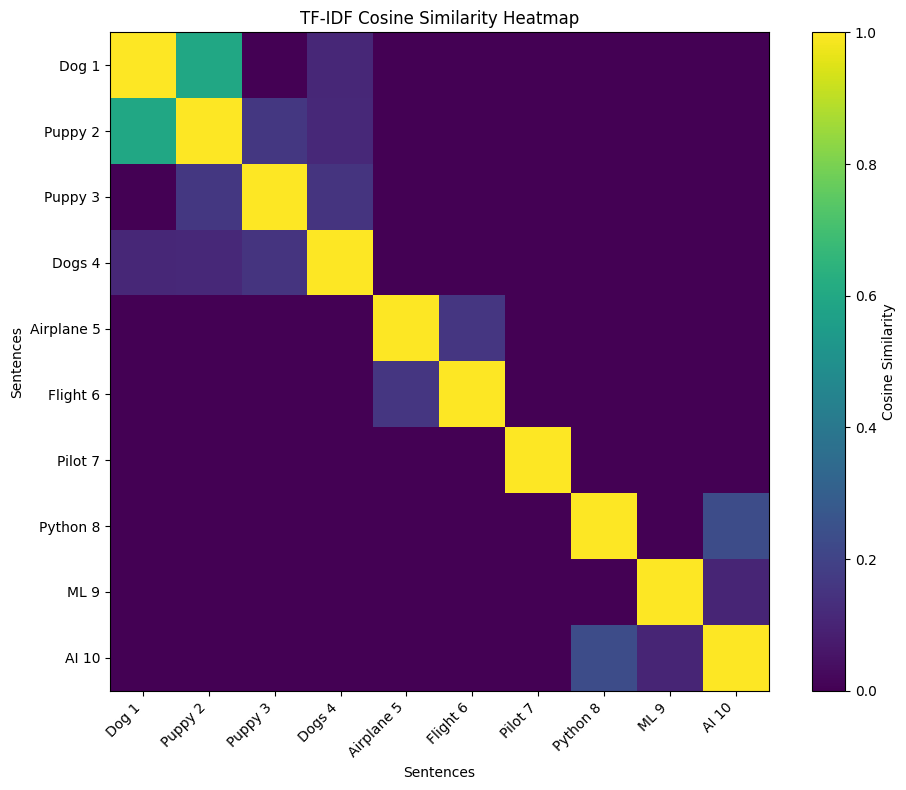

In [17]:
plt.figure(figsize=(10, 8))

plt.imshow(similarity_matrix, interpolation='nearest')

plt.colorbar(label='Cosine Similarity')

labels = [
    "Dog 1",
    "Puppy 2",
    "Puppy 3",
    "Dogs 4",
    "Airplane 5",
    "Flight 6",
    "Pilot 7",
    "Python 8",
    "ML 9",
    "AI 10"
]

plt.xticks(range(10), labels, rotation=45, ha='right')
plt.yticks(range(10), labels)

plt.xlabel("Sentences")
plt.ylabel("Sentences")
plt.title("TF-IDF Cosine Similarity Heatmap")

plt.tight_layout()
plt.show()

In [ ]:
# Conclusion

In this project, I converted natural language sentences into numerical vectors using TF-IDF.

TF-IDF assigns higher importance to words that are useful for distinguishing one document from another. Common words receive lower importance, while words that are more specific to particular documents receive higher importance.

After converting the sentences into vectors, I used cosine similarity to compare their directions in vector space.

The similarity matrix showed that sentences belonging to similar topics generally had higher similarity scores. For example, sentences about dogs and puppies were more closely related than sentences about dogs and airplanes.

The `find_similar()` function demonstrated how a new query can be compared against an existing corpus and ranked according to similarity.

However, TF-IDF has an important limitation: it mainly captures similarity through shared words rather than true semantic meaning. For example, "dog" and "puppy" are semantically related even though they are different words. TF-IDF cannot inherently understand this relationship unless their surrounding text contains overlapping vocabulary.

More advanced NLP techniques such as Word2Vec, GloVe, BERT, and Sentence Transformers create dense embeddings that can capture semantic relationships more effectively.

Therefore, this project demonstrates the fundamental idea behind semantic search:

Text → Numerical Representation → Vector Comparison → Similarity